In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv", sep=";", encoding="utf-8-sig")
df


,dataloadingdate,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,JourSemaine,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.60
1,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.50
2,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.60
3,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.60
4,01/07/2025,1,7,27,3,1,Tuesday,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19939,31/12/2024,31,12,1,4,1,Tuesday,TN0008000812,"BTA 7,5% 13/12/2028",215.0,0.200,50.0,9.00
19940,31/12/2024,31,12,1,4,1,Tuesday,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5243.0,0.556,15.0,7.49
19941,31/12/2024,31,12,1,4,1,Tuesday,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28288.0,3.000,31.0,8.99
19942,31/12/2024,31,12,1,4,1,Tuesday,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48701.0,5.165,31.0,8.99


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19944 entries, 0 to 19943
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataloadingdate   19944 non-null  object 
 1   Jour              19944 non-null  int64  
 2   Mois              19944 non-null  int64  
 3   NumeroSemaine     19944 non-null  int64  
 4   Trimestre         19944 non-null  int64  
 5   JourSemaineNum    19944 non-null  int64  
 6   JourSemaine       19944 non-null  object 
 7   ISIN              19944 non-null  object 
 8   Libellé           19944 non-null  object 
 9   Nombre de Titres  19944 non-null  float64
 10  Montant           19944 non-null  float64
 11  Echéance          19944 non-null  float64
 12  Taux              19944 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 2.0+ MB


In [24]:
df.describe()


,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,Nombre de Titres,Montant,Echéance,Taux
count,19944.000000,19944.000000,19944.000000,19944.000000,19944.000000,19944.000000,19944.000000,19944.000000,19944.000000
mean,14.841657,6.584136,26.578420,2.542870,1.949208,8872.550592,4.867922,40.106548,8.625240
std,9.071689,3.418794,14.887762,1.110532,1.473828,17043.278291,7.967361,61.110939,0.813669
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.001000,0.000000,5.800000
25%,7.000000,4.000000,14.000000,2.000000,1.000000,1073.000000,1.000000,10.000000,8.030000
50%,14.000000,7.000000,27.000000,3.000000,2.000000,3128.500000,2.001000,20.000000,8.970000
75%,23.000000,10.000000,40.000000,4.000000,3.000000,8742.000000,5.500000,32.000000,9.010000
max,31.000000,12.000000,52.000000,4.000000,4.000000,200000.000000,100.000000,365.000000,10.750000


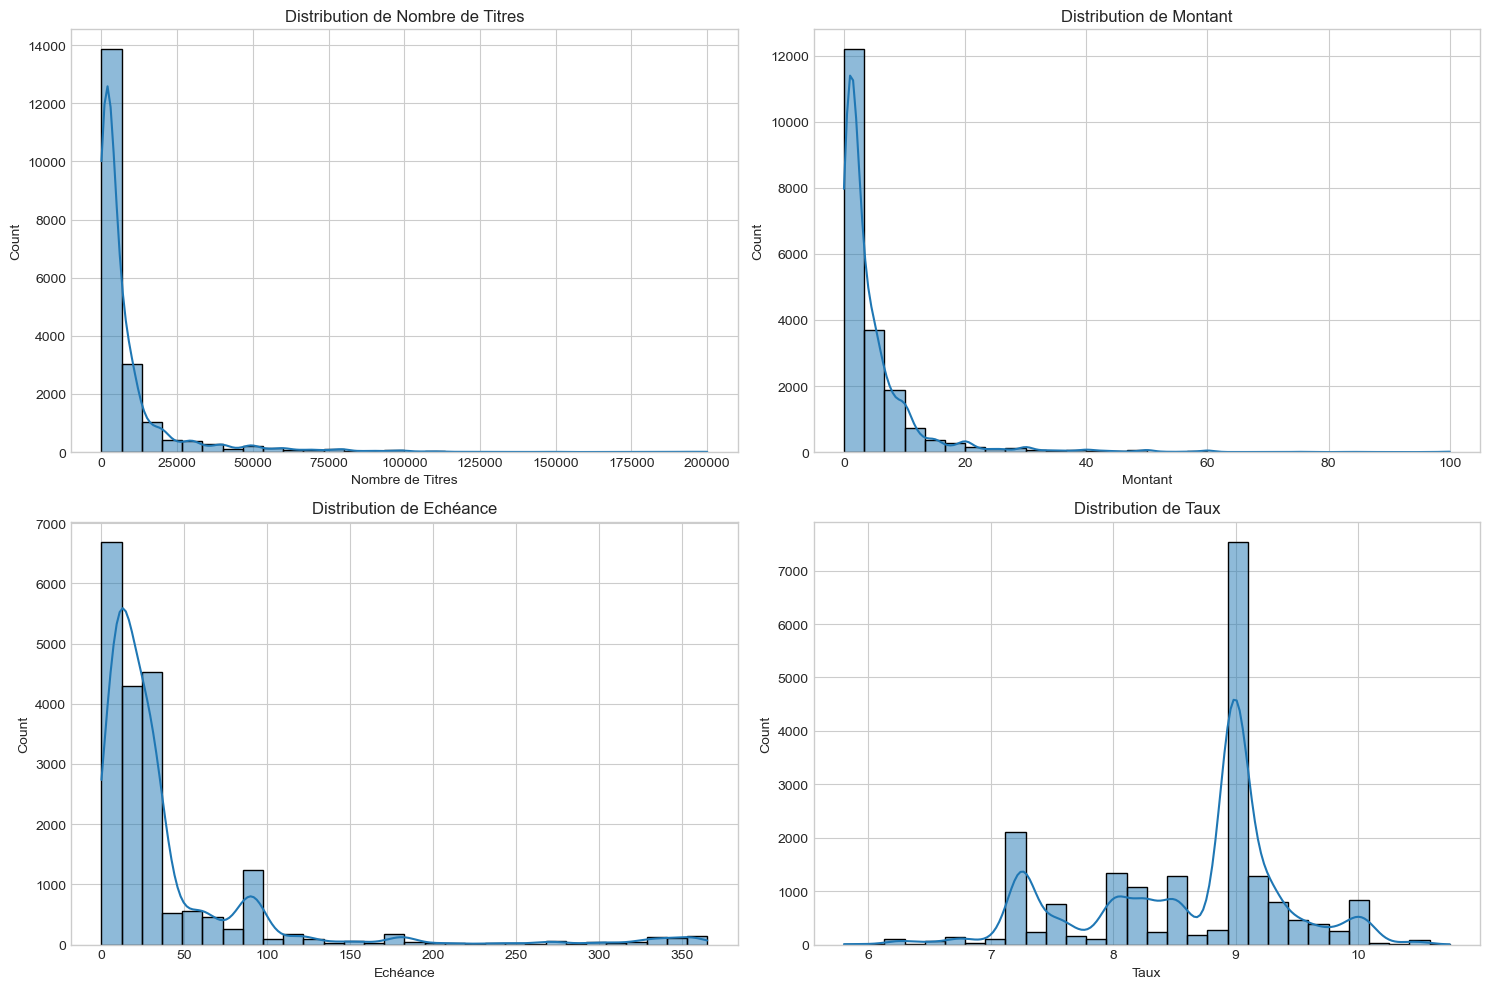

In [25]:
colonnes = ["Nombre de Titres", "Montant", "Echéance", "Taux"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(colonnes):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution de {col}")
plt.tight_layout()
plt.show()


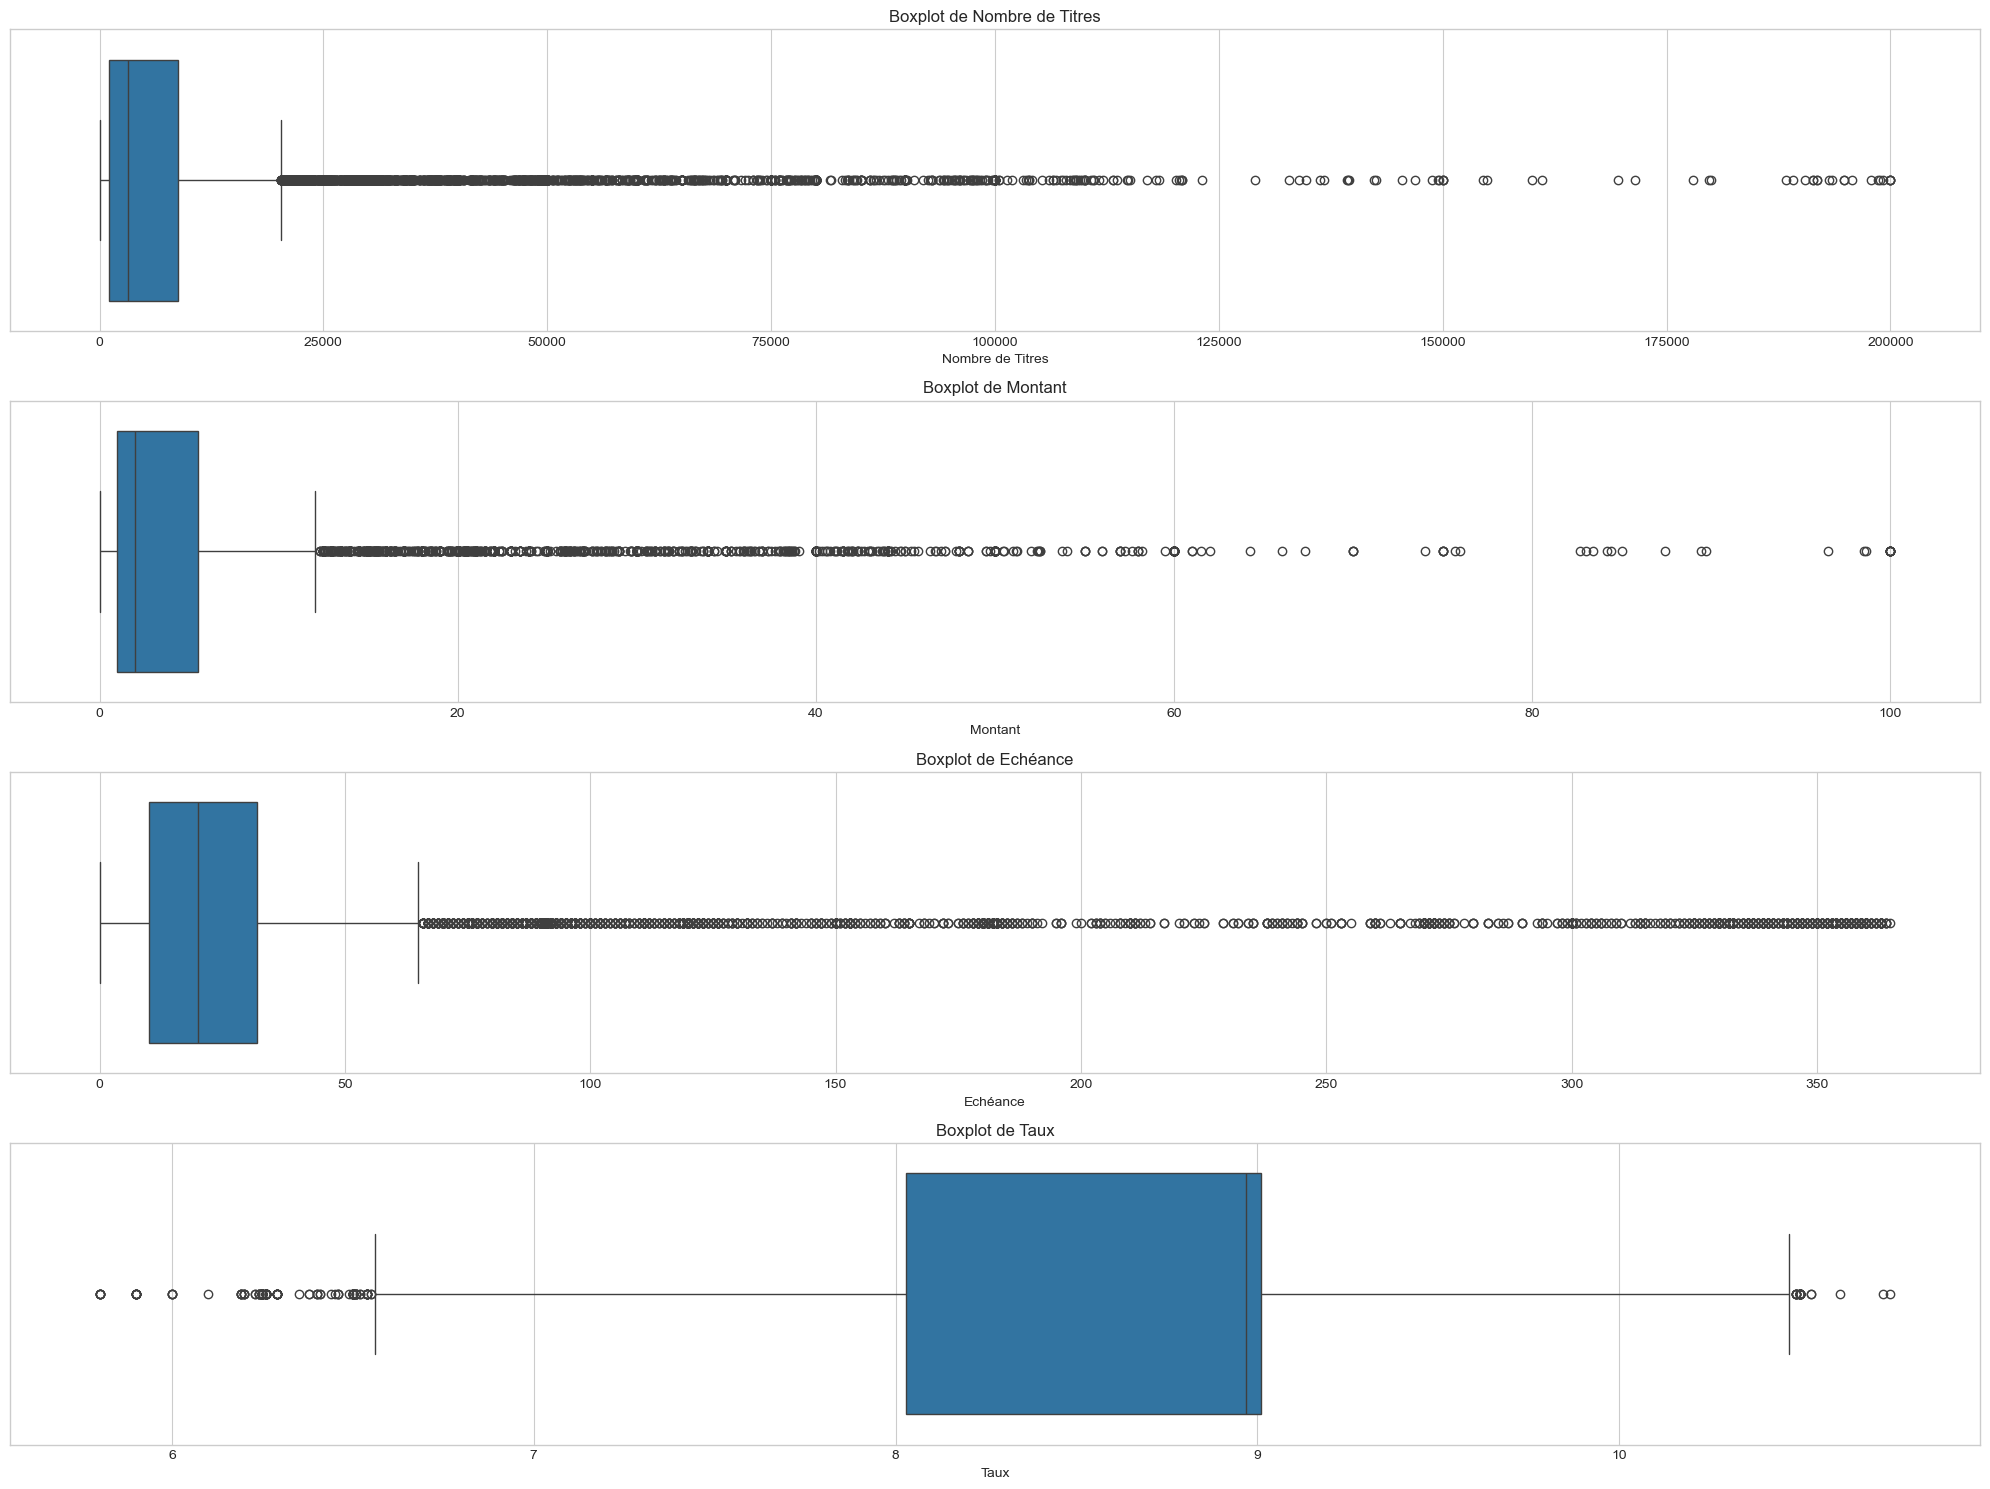

In [26]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(colonnes):
    plt.subplot(4, 1, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


In [27]:
colonnes = ['Nombre de Titres', 'Montant', 'Echéance', 'Taux']

# Taille des plots
plt.style.use("seaborn-v0_8-whitegrid")

for col in colonnes:
    print(f"\n📊 Analyse de la colonne : {col}")

    # Intervalle contenant la majorité des données (ex : 90%)
    q_low = df[col].quantile(0.05)
    q_high = df[col].quantile(0.95)
    print(f"📌 Intervalle réel contenant 90% des données : [{q_low:.2f}, {q_high:.2f}]")

    # Outliers basés sur IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"🚨 Nombre d'outliers détectés (IQR) : {outliers.count()}")

    # Statistiques complémentaires
    print(f"📉 Min réel : {df[col].min():.2f}")
    print(f"📈 Max réel : {df[col].max():.2f}")
    print(f"📊 Moyenne : {df[col].mean():.2f}")
    print(f"📍 Médiane : {df[col].median():.2f}")


📊 Analyse de la colonne : Nombre de Titres
📌 Intervalle réel contenant 90% des données : [280.00, 40000.00]
🚨 Nombre d'outliers détectés (IQR) : 2002
📉 Min réel : 1.00
📈 Max réel : 200000.00
📊 Moyenne : 8872.55
📍 Médiane : 3128.50

📊 Analyse de la colonne : Montant
📌 Intervalle réel contenant 90% des données : [0.22, 18.00]
🚨 Nombre d'outliers détectés (IQR) : 1538
📉 Min réel : 0.00
📈 Max réel : 100.00
📊 Moyenne : 4.87
📍 Médiane : 2.00

📊 Analyse de la colonne : Echéance
📌 Intervalle réel contenant 90% des données : [6.00, 147.00]
🚨 Nombre d'outliers détectés (IQR) : 3032
📉 Min réel : 0.00
📈 Max réel : 365.00
📊 Moyenne : 40.11
📍 Médiane : 20.00

📊 Analyse de la colonne : Taux
📌 Intervalle réel contenant 90% des données : [7.25, 9.89]
🚨 Nombre d'outliers détectés (IQR) : 241
📉 Min réel : 5.80
📈 Max réel : 10.75
📊 Moyenne : 8.63
📍 Médiane : 8.97


In [28]:
colonnes_numeriques = df.select_dtypes(include=[np.number]).columns

for col in colonnes_numeriques:
    nb_negatifs = (df[col] < 0).sum()
    print(f"➖ {col} : {nb_negatifs} valeur(s) négative(s)")


➖ Jour : 0 valeur(s) négative(s)
➖ Mois : 0 valeur(s) négative(s)
➖ NumeroSemaine : 0 valeur(s) négative(s)
➖ Trimestre : 0 valeur(s) négative(s)
➖ JourSemaineNum : 0 valeur(s) négative(s)
➖ Nombre de Titres : 0 valeur(s) négative(s)
➖ Montant : 0 valeur(s) négative(s)
➖ Echéance : 0 valeur(s) négative(s)
➖ Taux : 0 valeur(s) négative(s)


c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


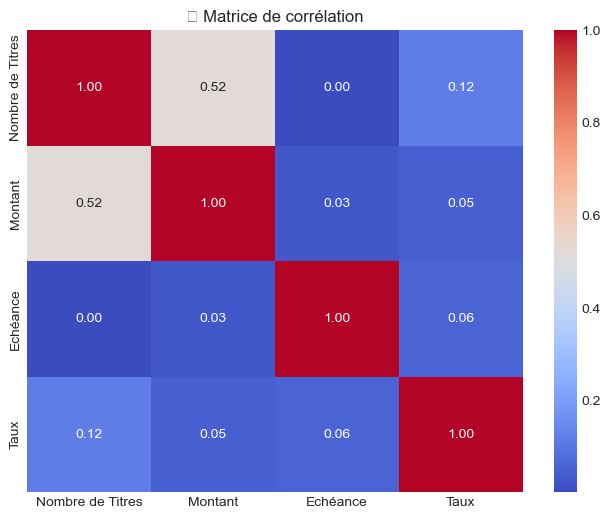

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colonnes].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔗 Matrice de corrélation")
plt.show()


In [12]:
# --- 1. Statistiques descriptives groupées ---

print("Statistiques Montant par Jour de la Semaine :")
print(df.groupby('JourSemaine')['Montant'].describe())

print("\nStatistiques Montant par Mois :")
print(df.groupby('Mois')['Montant'].describe())

print("\nStatistiques Montant par Année :")
print(df.groupby('Année')['Montant'].describe())

Statistiques Montant par Jour de la Semaine :
              count      mean       std    min  25%   50%    75%      max
JourSemaine                                                              
Friday       4212.0  4.374936  6.630033  0.005  1.0  2.00  5.001   61.501
Monday       4790.0  5.502030  9.353924  0.002  1.0  2.30  6.000   99.999
Thursday     3753.0  4.564913  7.569721  0.008  1.0  2.00  5.001  100.000
Tuesday      3610.0  4.952005  7.978832  0.001  1.0  2.20  5.642  100.000
Wednesday    3579.0  4.832364  7.729432  0.003  1.0  2.04  5.501  100.000

Statistiques Montant par Mois :
       count      mean       std    min   25%    50%      75%      max
Mois                                                                  
1     1637.0  4.756931  7.707237  0.010  1.00  2.001  5.00000   84.999
2     1534.0  4.630211  7.997636  0.012  0.92  2.000  5.00000   99.999
3     1417.0  4.589919  7.900442  0.007  0.85  2.000  5.00000   99.999
4     1651.0  5.070595  8.274310  0.016  1.00  2

=== Matrice de corrélation ===


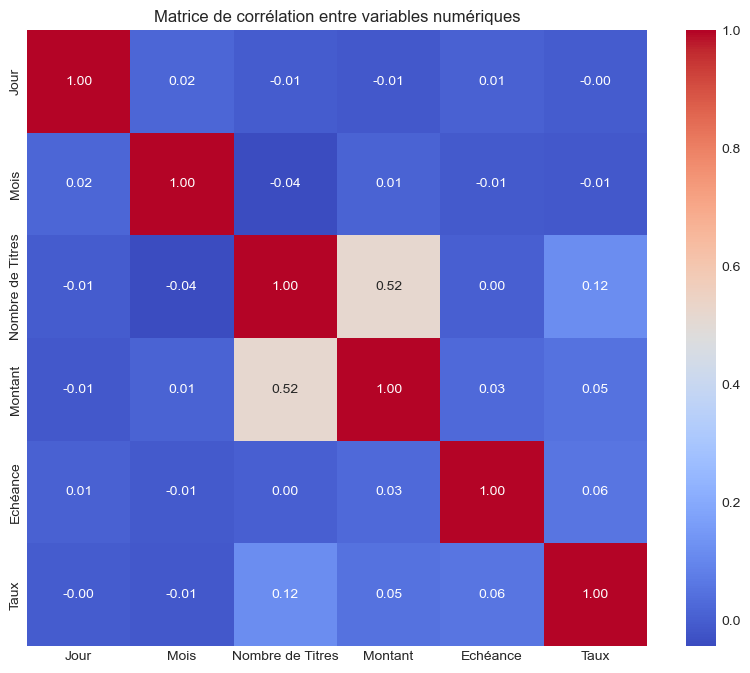

In [18]:
# Nettoyage / conversion des colonnes en numérique si nécessaire
colonnes_numeriques = ["Jour", "Mois", "Nombre de Titres", "Montant", "Echéance", "Taux"]



# Supprimer les lignes avec NaN dans ces colonnes pour calculer corrélation proprement
df_corr = df[colonnes_numeriques].dropna()

# Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

print("=== Matrice de corrélation ===")

# Visualisation avec heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice de corrélation entre variables numériques")
plt.show()

In [14]:
grouped_jour = df.groupby('JourSemaine')['Montant'].agg(['mean', 'std']).reindex(order_jour)
print("\nMoyenne et écart-type du Montant par Jour de la Semaine :")
print(grouped_jour)


Moyenne et écart-type du Montant par Jour de la Semaine :
                 mean       std
JourSemaine                    
Monday       5.502030  9.353924
Tuesday      4.952005  7.978832
Wednesday    4.832364  7.729432
Thursday     4.564913  7.569721
Friday       4.374936  6.630033
Saturday          NaN       NaN
Sunday            NaN       NaN


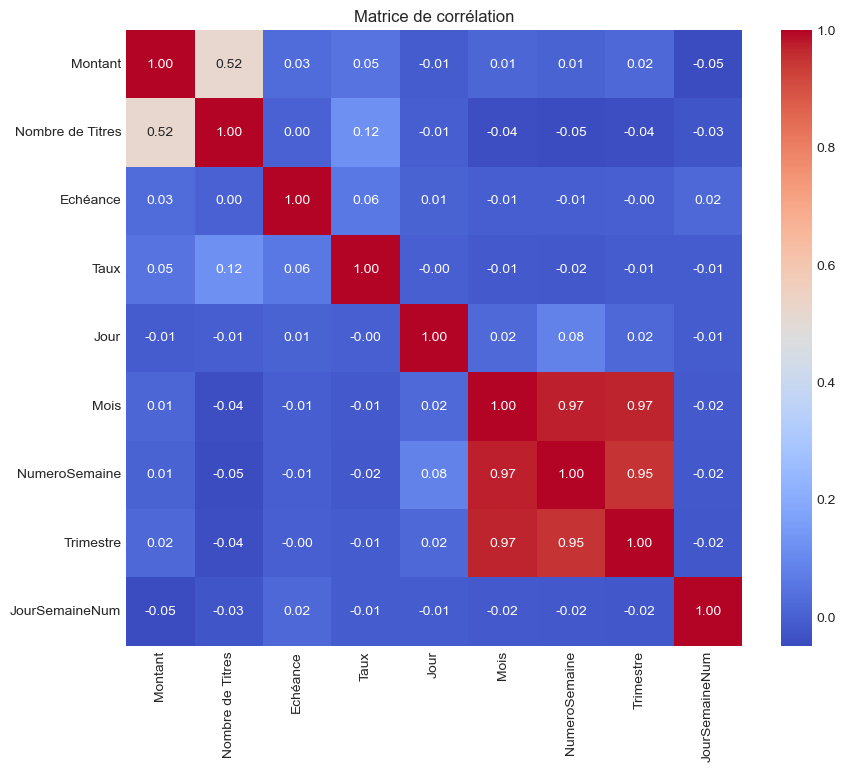

In [29]:
# Sélection des colonnes numériques utiles
colonnes_num = ["Montant", "Nombre de Titres", "Echéance", "Taux", "Jour", "Mois", "NumeroSemaine", "Trimestre", "JourSemaineNum"]

corr = df[colonnes_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation")
plt.show()


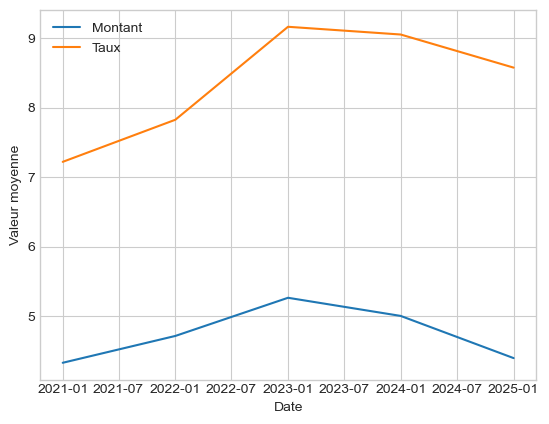

In [46]:
df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], dayfirst=True)

df_mensuel = df.groupby(df['dataloadingdate'].dt.to_period('Y')).agg({
    'Montant': 'mean',
    'Taux': 'mean'
}).reset_index()

df_mensuel['dataloadingdate'] = df_mensuel['dataloadingdate'].dt.to_timestamp()

plt.plot(df_mensuel['dataloadingdate'], df_mensuel['Montant'], label='Montant')
plt.plot(df_mensuel['dataloadingdate'], df_mensuel['Taux'], label='Taux')
plt.xlabel('Date')
plt.ylabel('Valeur moyenne')
plt.legend()
plt.grid(True)
plt.show()


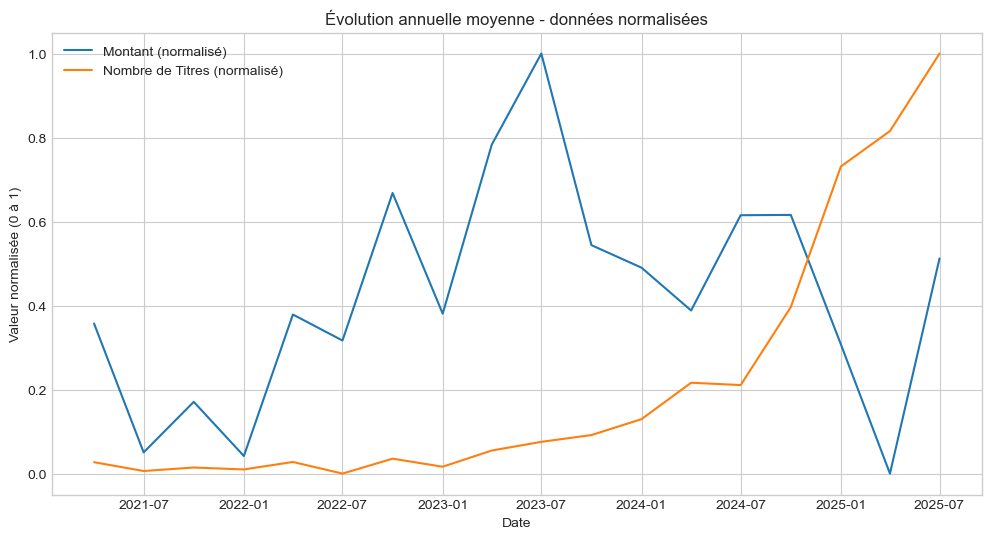

In [62]:
import matplotlib.pyplot as plt

# Assure-toi que la colonne est en datetime
df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], dayfirst=True)

# Agrégation annuelle moyenne
df_annuel = df.groupby(df['dataloadingdate'].dt.to_period('Q')).agg({
    'Montant': 'mean',
    'Nombre de Titres': 'mean'
}).reset_index()

df_annuel['dataloadingdate'] = df_annuel['dataloadingdate'].dt.to_timestamp()

# Normalisation min-max sur chaque colonne
def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

df_annuel['Montant_norm'] = min_max_norm(df_annuel['Montant'])
df_annuel['Nombre_de_Titres_norm'] = min_max_norm(df_annuel['Nombre de Titres'])

# Tracé des données normalisées
plt.figure(figsize=(12,6))
plt.plot(df_annuel['dataloadingdate'], df_annuel['Montant_norm'], label='Montant (normalisé)')
plt.plot(df_annuel['dataloadingdate'], df_annuel['Nombre_de_Titres_norm'], label='Nombre de Titres (normalisé)')
plt.xlabel('Date')
plt.ylabel('Valeur normalisée (0 à 1)')
plt.title('Évolution annuelle moyenne - données normalisées')
plt.legend()
plt.grid(True)
plt.show()


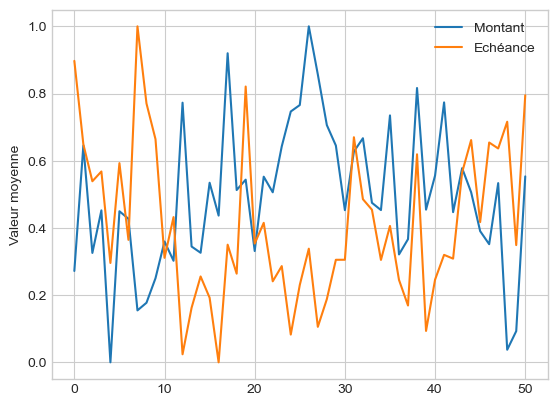

In [66]:
df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], dayfirst=True)

df_mensuel = df.groupby(df['dataloadingdate'].dt.to_period('M')).agg({
    'Montant': 'mean',
    'Echéance': 'mean'
}).reset_index()

def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

df_mensuel['Montant_norm'] = min_max_norm(df_mensuel['Montant'])
df_mensuel['Echéance_norm'] = min_max_norm(df_mensuel['Echéance'])
df_mensuel['dataloadingdate'] = df_mensuel['dataloadingdate'].dt.to_timestamp()

plt.plot(df_mensuel['Montant_norm'], label='Montant')
plt.plot( df_mensuel['Echéance_norm'], label='Echéance')
plt.ylabel('Valeur moyenne')
plt.legend()
plt.grid(True)
plt.show()
